# 篇末综合 测量辨识与验证的综合实验

## 学习目标与先修知识

能将测量时钟、连续/离散表示、参数（parameter）估计和独立验证组成完整计算链；能说明一个小残差（residual）仍不能排除哪些解释。

先修：本篇第 6.1—6.6 章的采样（sampling）、频谱、最小二乘、数据划分、两种预测与递推辨识。
[复习本篇](../README.md)。

## 具体问题

两组理想培养室实验分别测量停供后的清除，以及有输入（input）时的动态响应。你能否得到一个在新输入下仍可用的模型（model）？我们先分别检查表示、参数和信息边界，再讨论能否连接。八道练习各有完整输入，无需把前题答案交给后题。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE,PINK,GREEN,GRAY='#008bfb','#ff0051','#009e73','#555555'

## 初步实验

In [2]:
observed=[0.,1.,2.,2.]
inputs=[1.,1.,0.]
one=[.5*observed[n]+u for n,u in enumerate(inputs)]
free=[];current=observed[0]
for u in inputs:
    current=.5*current+u
    free.append(current)
display(Markdown(show_table(['目标时刻','观测','一步预测','自由运行'],[[n+1,observed[n+1],one[n],free[n]] for n in range(3)])))

| 目标时刻 | 观测 | 一步预测 | 自由运行 |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 1 |
| 2 | 2 | 1.5 | 1.5 |
| 3 | 2 | 1 | 0.75 |

## 模型假设

这是用于整合方法的理想教学实验，参数不是生理标定值。所追踪物质总量（tracked amount） A 的单位为 U，时间为 T，输入流率（flow rate）为 U/T；各输入区间内保持恒定，清除满足 A′=u−kA、k≥0。拟合清除曲线时停止输入，初始量由独立协议给定为 5 U，候选 k 属于明确有限集合。

动态回归另外用观测（observation）序列 y 和区间输入构成一阶外源输入自回归模型（autoregressive with exogenous input，ARX）：y[n+1]=a y[n]+b u[n]+e[n+1]。a 无量纲（dimensionless），b 的单位 T；若测量链与连续单室假设都成立，才可进一步解释 a=exp(−kh)、b=(1−a)/k。任意独立拟合的 a、b 不自动满足这个物理约束。

本节小数组（array）是题设读数，用于独立检算，不用它们声称区间覆盖率或普遍泛化性能。已固定参数的预测评估，与候选参数的拟合是不同实验。

## 数学解释与推导

先从同一连续方程积分，在每个长度 h 的区间得到
$$A_{n+1}=e^{-kh}A_n+u_n\int_0^h e^{-k\tau}\,d\tau
=aA_n+bu_n.$$
k=0 时积分为 h，不能直接除以 0。Euler 近似则用区间起点变化率，A[n+1]=(1−kh)A[n]+hu[n]。即使精确响应非负，Euler 大步长仍可能产生负值。

停供观测的候选预测为 p_i(k)=A₀exp(−kt_i)，残差 r_i=y_i−p_i。本综合用误差方差（variance）的倒数作为权重 wᵢ，单位 1/U²。本例数值 [1,2,1] 对应标准差（standard deviation） [1,1/√2,1] U。对给定正权重，比较 S(k)=Σwᵢrᵢ²，损失无量纲；这只给出候选集内的最优值。若把误差解释为独立高斯测量误差，权重与其方差倒数成比例。不能把对数变换或先差分看成保留原误差模型的免费操作。

预处理也属于模型拟合。预先固定 t_train、t_validation，将有效原始索引分到 t<t_train、t_train≤t<t_validation、其余三段。只用训练值计算 μ、s=√(Σ(x−μ)²/N_train)，再应用 z=(x−μ)/s；常数训练段约定 s=1 U。缺测仍为 None，不能删去后把两拍间隔当一拍。

一步预测（one-step-ahead prediction）使用已到达的 y[n]：ŷ[n+1|n]=a y[n]+b u[n]。自由运行（free-run simulation）只在段起点读一次观测：ỹ[n+1]=aỹ[n]+b u[n]。两种均方根误差（root mean squared error，RMSE）都相对于同一组目标 y[1:]：
$$\operatorname{RMSE}=\sqrt{\frac1N\sum_{n=0}^{N-1}(\widehat y_{n+1}-y_{n+1})^2}.$$
公共初态不是预测成功，不能额外放入分母。一步预测隐含每一步会继续得到新观测，自由运行对应整段不再观察；二者回答不同使用问题。

## 核心实现

In [3]:
def sampled_response(k, step, initial, inputs):
    a=math.exp(-k*step);b=step if k==0 else -math.expm1(-k*step)/k
    exact=[initial];euler=[initial]
    for u in inputs:
        exact.append(a*exact[-1]+b*u)
        euler.append((1-k*step)*euler[-1]+step*u)
    return exact,euler


def fit_clearance_grid(times, observed, initial, candidates, weights):
    candidates=sorted(set(candidates))
    best=None
    for k in candidates:
        predicted=[initial*math.exp(-k*t) for t in times]
        residuals=[y-p for y,p in zip(observed,predicted)]
        score=sum(w*r*r for w,r in zip(weights,residuals))
        if best is None or score<best[3]:best=(k,predicted,residuals,score)
    return best


def train_standardize(times, values, train_end, validation_end):
    train=[];validation=[];test=[]
    for i,(t,x) in enumerate(zip(times,values)):
        if x is None:continue
        if t<train_end:train.append(i)
        elif t<validation_end:validation.append(i)
        else:test.append(i)
    mean=sum(values[i] for i in train)/len(train)
    scale=math.sqrt(sum((values[i]-mean)**2 for i in train)/len(train))
    if scale==0:scale=1.
    transformed=[None if x is None else (x-mean)/scale for x in values]
    return train,validation,test,mean,scale,transformed


def prediction_scores(a, b, observed, inputs):
    one=[a*observed[n]+b*u for n,u in enumerate(inputs)]
    free=[];current=observed[0]
    for u in inputs:
        current=a*current+b*u;free.append(current)
    targets=observed[1:]
    one_rmse=math.sqrt(sum((p-y)**2 for p,y in zip(one,targets))/len(targets))
    free_rmse=math.sqrt(sum((p-y)**2 for p,y in zip(free,targets))/len(targets))
    return one,free,one_rmse,free_rmse

## 对照实验

左图检验清除候选，右图只改变评估信息条件。输入数据不含“真实参数”字段，拟合过程无法借用答案。

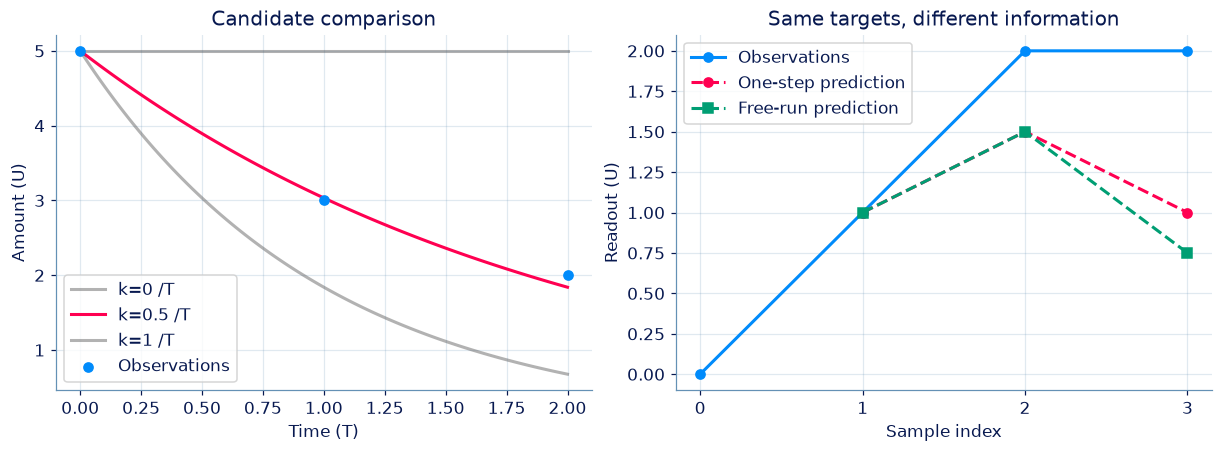

| 量 | 结果 |
| --- | --- |
| 候选最优 k (/T) | 0.5 |
| 加权损失 (无量纲) | 0.0279257 |
| 一步 RMSE (U) | 0.645497 |
| 自由运行 RMSE (U) | 0.777282 |

In [4]:
times=[0.,1.,2.];measured=[5.,3.,2.]
candidates=[0.,.5,1.];weights=[1.,2.,1.]
best,predicted,residuals,loss=fit_clearance_grid(times,measured,5.,candidates,weights)
one,free,one_error,free_error=prediction_scores(.5,1.,observed,inputs)
fig,axes=plt.subplots(1,2,figsize=(11,4))
grid=np.linspace(0,2,101)
for k in candidates:
    axes[0].plot(grid,5*np.exp(-k*grid),label=f'k={k:g} /T',color=PINK if k==best else GRAY,alpha=1 if k==best else .45)
axes[0].scatter(times,measured,color=BLUE,label='Observations',zorder=4)
axes[0].set(xlabel='Time (T)',ylabel='Amount (U)',title='Candidate comparison')
axes[1].plot(range(4),observed,'o-',color=BLUE,label='Observations')
axes[1].plot(range(1,4),one,'o--',color=PINK,label='One-step prediction')
axes[1].plot(range(1,4),free,'s--',color=GREEN,label='Free-run prediction')
axes[1].set(xlabel='Sample index',ylabel='Readout (U)',xticks=range(4),title='Same targets, different information')
for ax in axes:ax.legend()
plt.show()
display(Markdown(show_table(['量','结果'],[['候选最优 k (/T)',best],['加权损失 (无量纲)',loss],['一步 RMSE (U)',one_error],['自由运行 RMSE (U)',free_error]])))

## 结果解释

有限候选得到 k=0.5/T；这不是连续参数空间最优的证明。初始量固定也并不表示现实测量没有初值（initial condition）误差，放宽这一前提要重新定义参数与误差模型。

自由运行偏差可累积，一步预测则持续利用新读数纠偏。本例一步误差较小；这不保证任意数据上两者存在固定大小关系。相同目标和对齐方式使比较有意义，但不消除使用条件的差异。

若强输入下出现持续偏差，应报告激励范围，提出饱和等候选解释，再设计区分实验。用最终评估数据修改方案后，需要新的未见评估。把验证误差变小、把回归矩阵（matrix）变成满秩（rank）、恢复真实机制，是三个不同判断。

### 独立核对与迁移

下列手算参照检查一次区间积分、原始索引、训练统计量（statistic）不受后段改变、共同初态不计入误差。随后可以改变清除网格或输入片段，但应先固定要比较的误差定义。

In [5]:
exact,euler=sampled_response(.25,2.,2.,[1.])
assert math.isclose(exact[1],4-2*math.exp(-.5))
assert euler==[2.,3.]
partition=train_standardize([0.,1.,2.,3.,4.,5.],[1.,3.,None,5.,7.,9.],2.,4.)
assert partition[:3]==([0,1],[3],[4,5])
assert partition[3:5]==(2.,1.)
changed=train_standardize([0.,1.,2.,3.,4.,5.],[1.,3.,None,-50.,700.,900.],2.,4.)
assert changed[3:5]==partition[3:5]
assert math.isclose(one_error,math.sqrt(1.25/3))
assert math.isclose(free_error,math.sqrt(1.8125/3))
assert math.isclose(loss,2*(3-5*math.exp(-.5))**2+(2-5*math.exp(-1))**2)
print('区间积分、时间边界、训练隔离和误差分母均通过独立核对。')

区间积分、时间边界、训练隔离和误差分母均通过独立核对。


### 从固定参数到在线跟踪

当交换与清除缓慢漂移时，把读数逐条加入并不意味着可以在看过当前目标后才计算“预测”。沿用6.6的指数遗忘目标，初始正则权重也衰减；下方先用调参前缀选择因子，再在留出时段按同一时钟继续更新。

先用4条无量纲标量回归读数，逐步核对预测、评分与更新的顺序。两候选在指定调参段严格并列，按公开规则选较小因子；留出读数不能打破调参并列。

In [6]:
def rls_trace(regressors, observed, initial_parameters, initial_inverse, forgetting):
    parameters = initial_parameters.copy()
    inverse = [row.copy() for row in initial_inverse]
    dimension = len(parameters)
    predictions, parameter_history, inverse_history = [], [], []
    for features, target in zip(regressors, observed):
        prediction = sum(x * b for x, b in zip(features, parameters))
        direction = [sum(inverse[i][j] * features[j] for j in range(dimension))
                     for i in range(dimension)]
        denominator = forgetting + sum(x * v for x, v in zip(features, direction))
        gain = [v / denominator for v in direction]
        error = target - prediction
        parameters = [b + g * error for b, g in zip(parameters, gain)]
        inverse = [[(inverse[i][j] - direction[i] * direction[j] / denominator) / forgetting
                    for j in range(dimension)] for i in range(dimension)]
        predictions.append(prediction)
        parameter_history.append(parameters.copy())
        inverse_history.append([row.copy() for row in inverse])
    return predictions, parameter_history, inverse_history

def select_forgetting(regressors, observed, candidates, initial_parameters,
                      initial_inverse, tuning_start, evaluation_start):
    tuning_scores = []
    for forgetting in sorted(set(candidates)):
        predictions, _, _ = rls_trace(
            regressors[:evaluation_start], observed[:evaluation_start],
            initial_parameters, initial_inverse, forgetting)
        errors = [(predictions[i] - observed[i]) ** 2
                  for i in range(tuning_start, evaluation_start)]
        tuning_scores.append((sum(errors) / len(errors), forgetting))
    chosen = min(tuning_scores)[1]
    predictions, parameter_history, _ = rls_trace(
        regressors, observed, initial_parameters, initial_inverse, chosen)
    test_errors = [(predictions[i] - observed[i]) ** 2
                   for i in range(evaluation_start, len(observed))]
    score = (sum(test_errors) / len(test_errors)) ** 0.5
    return chosen, parameter_history[-1], score


In [7]:
chosen, final_parameters, held_out_rmse = select_forgetting(
    [[1.]]*4, [0., 0., 2., 2.], [1., .5], [0.], [[1.]], 1, 3)
assert chosen == .5
np.testing.assert_allclose(final_parameters, [48/31])
assert np.isclose(held_out_rmse, 14/15)
changed = select_forgetting([[1.]]*4, [0., 0., 2., -10.], [1., .5], [0.], [[1.]], 1, 3)
assert changed[0] == chosen
display(Markdown(show_table(['所选λ', '最后更新参数', '留出在线RMSE'], [(chosen, final_parameters[0], held_out_rmse)])))

| 所选λ | 最后更新参数 | 留出在线RMSE |
| --- | --- | --- |
| 0.5 | 1.54839 | 0.933333 |

## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：采样改变了什么

理想节律含0.2 Hz和0.8 Hz，fs=1 Hz；算法另用0.001 s数值步长。哪些正确？

- **A.** 使用未来点的居中滤波应标为离线或注明等待延迟（delay）。
- **B.** 给1秒采样（sampling）记录补零即可恢复两个连续成分。
- **C.** 提高观察采样率（sampling rate）并满足带宽条件可以减少这种歧义。
- **D.** 更细数值步长不改变每秒一次读数的混叠（aliasing）歧义。

[作答：采样改变了什么](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-sampling)

### 第 2 题 · 基础辨析 · 10 分 · 多项选择题：哪些激励有助于辨识

a、b独立未知的ARX只在一个非零稳态取了1000次相同条件读数。哪些解释合理？

- **A.** 1000点一定比10点任何动态设计更可辨识。
- **B.** 满列秩（rank）之后仍需检查误差假设与独立验证。
- **C.** 重复可以减少某些随机误差，却不能自动打破稳态参数（parameter）组合的混淆。
- **D.** 设计过渡或变化输入（input），再检查回归列是否提供独立方向。

[作答：哪些激励有助于辨识](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-excitation)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：连接区间输入与离散响应

给定独立的输入（input）片段，计算单室模型（one-compartment model）的精确零阶保持（zero-order hold，ZOH）与Euler轨迹（trajectory），作为后续评估之外的独立表示检查。

**函数与代码模板**

```python
def solve(
    k: float,
    step: float,
    initial: float,
    inputs: list[float],
) -> tuple[list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `step` | `float` | 每段输入保持的时长/采样（sampling）间隔。 | T |
| `initial` | `float` | 起点所追踪物质总量（tracked amount）。 | U |
| `inputs` | `list[float]` | 每个区间内保持不变的输入流率（flow rate）。 | U/T |

**返回值**

按以下顺序返回元组：(exact, euler)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `exact` | `list[float]` | 精确零阶保持轨迹，含初态。 | U |
| `euler` | `list[float]` | 显式Euler轨迹，含初态且保留负值。 | U |

**计算规则**

a=exp(−k*step)，b=(1−a)/k；k=0时b=step。精确更新A_next=a*A+b*u。Euler更新A_next=(1−k*step)*A+step*u。各自递推，均含初态，不裁剪负值。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0≤k≤1；0.01≤step≤4；0≤initial≤20；0—12段输入，各0≤u≤5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 清除系数（elimination rate constant）。 | 0.25 | 1/T |
| step | 每段输入保持的时长/采样（sampling）间隔。 | 2 | T |
| initial | 起点所追踪物质总量（tracked amount）。 | 2 | U |
| inputs | 每个区间内保持不变的输入流率（flow rate）。 | [1.0, 0.0, 2.0] | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.25
step = 2.0
initial = 2.0
inputs = [1.0, 0.0, 2.0]

result = solve(k, step, initial, inputs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| exact | 精确零阶保持轨迹，含初态。 | [2.0, 2.7869386805747336, 1.6903637565076493, 4.173012166687843] | U |
| euler | 显式Euler轨迹，含初态且保留负值。 | [2.0, 3.0, 1.5, 4.75] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.0,
                    2.7869386805747336,
                    1.6903637565076493,
                    4.173012166687843],
                   [2.0, 3.0, 1.5, 4.75])
```

**样例解释**

第一段精确值为2e⁻⁰·⁵+4(1−e⁻⁰·⁵)≈2.78694 U；Euler为3 U。两条轨迹随后各自递推。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：连接区间输入与离散响应](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-discrete)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：参数估计与残差

只用给定拟合观测（observation）比较候选清除参数（parameter）。核验真值不作为函数参数，初始量由独立测量协议给定。

**函数与代码模板**

```python
def solve(
    times: list[float],
    observed: list[float],
    initial: float,
    candidates: list[float],
    weights: list[float],
) -> tuple[float, list[float], list[float], float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 无输入（input）清除开始后的观察时刻。 | T |
| `observed` | `list[float]` | 对应读数，可含测量误差。 | U |
| `initial` | `float` | 独立给定的初始所追踪物质总量（tracked amount），本题不拟合。 | U |
| `candidates` | `list[float]` | 待比较的清除系数（elimination rate constant）有限集合，可以未排序或重复。 | 1/T |
| `weights` | `list[float]` | 每个读数平方残差（residual）的正权重。 | 1/U² |

**返回值**

按以下顺序返回元组：(best_k, predicted, residuals, weighted_sse)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `best_k` | `float` | 有限候选中目标最小者，完全并列选较小k。 | 1/T |
| `predicted` | `list[float]` | 在观测时刻的拟合值。 | U |
| `residuals` | `list[float]` | observed−predicted。 | U |
| `weighted_sse` | `float` | Σweights[i]*residuals[i]²。 | 1 |

**计算规则**

每个k的预测为initial*exp(−k*t)。比较给定加权平方误差和；候选去重后升序扫描，只有严格更小的损失才更新。返回的最优仅限此候选集合。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 等长1—30个times/observed/weights；0≤t≤20，|observed|≤30，0<weights≤100；0≤initial≤20；1—30个候选，0≤k≤2。测试非完全并列时目标差>1e−8。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 无输入（input）清除开始后的观察时刻。 | [0.0, 1.0, 2.0] | T |
| observed | 对应读数，可含测量误差。 | [5.0, 3.0, 2.0] | U |
| initial | 独立给定的初始所追踪物质总量（tracked amount），本题不拟合。 | 5 | U |
| candidates | 待比较的清除系数（elimination rate constant）有限集合，可以未排序或重复。 | [0.0, 0.5, 1.0] | 1/T |
| weights | 每个读数平方残差（residual）的正权重。 | [1.0, 2.0, 1.0] | 1/U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0, 2.0]
observed = [5.0, 3.0, 2.0]
initial = 5.0
candidates = [0.0, 0.5, 1.0]
weights = [1.0, 2.0, 1.0]

result = solve(times, observed, initial, candidates, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| best_k | 有限候选中目标最小者，完全并列选较小k。 | 0.5 | 1/T |
| predicted | 在观测时刻的拟合值。 | [5.0, 3.032653298563167, 1.8393972058572117] | U |
| residuals | observed−predicted。 | [0.0, -0.0326532985631669, 0.16060279414278833] | U |
| weighted_sse | Σweights[i]*residuals[i]²。 | ≈ 0.02792573 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5,
                   [5.0,
                    3.032653298563167,
                    1.8393972058572117],
                   [0.0,
                    -0.0326532985631669,
                    0.16060279414278833],
                   0.02792573330058148)
```

**样例解释**

候选0.5/T的加权损失约0.0279257，比0及1/T小；保留原单位残差，不把它们对数化。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：参数估计与残差](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-fit)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：划分数据并隔离标准化

给定三段固定时间边界。先排除缺测并划分索引，再仅从训练段有效读数求均值和总体标准差（standard deviation），把固定变换应用于所有非缺测值。

**函数与代码模板**

```python
def solve(
    times: list[float],
    values: list[float | None],
    train_end: float,
    validation_end: float,
) -> tuple[list[int], list[int], list[int], float, float, list[float | None]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 严格递增的观察时刻。 | T |
| `values` | <code>list[float &#124; None]</code> | 同长度读数；None明确表示缺测。 | U |
| `train_end` | `float` | 训练区间右边界，不包含该时刻。 | T |
| `validation_end` | `float` | 验证区间右边界，不包含该时刻。 | T |

**返回值**

按以下顺序返回元组：(train_indices, validation_indices, test_indices, training_mean, training_scale, standardized)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `train_indices` | `list[int]` | 有效且t<train_end的原始索引。 | 索引 |
| `validation_indices` | `list[int]` | 有效且train_end≤t<validation_end的原始索引。 | 索引 |
| `test_indices` | `list[int]` | 有效且t≥validation_end的原始索引。 | 索引 |
| `training_mean` | `float` | 训练有效读数均值。 | U |
| `training_scale` | `float` | 训练总体标准差；全相同则取1 U作为约定。 | U |
| `standardized` | <code>list[float &#124; None]</code> | 与values等长，缺测仍为None，其余按训练变换处理。 | 1 |

**计算规则**

先按原时间边界分组，缺测值不加入任何索引；保留原始索引，不把缺测删除后的相邻项当成相邻时间步。均值与标准差都只由train_indices中的读数计算，方差（variance）分母为有效训练点数。标准差为0时将scale设为1，再输出（output）(x−mean)/scale。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 0—100 个严格递增时刻，与values等长；绝对值≤1000；train_end<validation_end；非缺测读数绝对值≤100。
- 至少一个有效训练点；训练标准差非零时≥1e−6。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 严格递增的观察时刻。 | [0.0, 1.0, 2.0, 3.0, 4.0, 5.0] | T |
| values | 同长度读数；None明确表示缺测。 | [1.0, 3.0, None, 5.0, 7.0, 9.0] | U |
| train_end | 训练区间右边界，不包含该时刻。 | 2 | T |
| validation_end | 验证区间右边界，不包含该时刻。 | 4 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
values = [1.0, 3.0, None, 5.0, 7.0, 9.0]
train_end = 2.0
validation_end = 4.0

result = solve(times, values, train_end, validation_end)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| train_indices | 有效且t<train_end的原始索引。 | [0, 1] | 索引 |
| validation_indices | 有效且train_end≤t<validation_end的原始索引。 | [3] | 索引 |
| test_indices | 有效且t≥validation_end的原始索引。 | [4, 5] | 索引 |
| training_mean | 训练有效读数均值。 | 2 | U |
| training_scale | 训练总体标准差；全相同则取1 U作为约定。 | 1 | U |
| standardized | 与values等长，缺测仍为None，其余按训练变换处理。 | [-1.0, 1.0, None, 3.0, 5.0, 7.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 1],
                   [3],
                   [4, 5],
                   2.0,
                   1.0,
                   [-1.0, 1.0, None, 3.0, 5.0, 7.0])
```

**样例解释**

训练索引[0,1]，验证[3]，最终[4,5]；训练均值2 U、scale=1 U；标准化为[−1,1,None,3,5,7]，后段的大读数不改变训练变换。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：划分数据并隔离标准化](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-preprocess)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：两种预测的误差分别是多少

参数（parameter）已固定，已知评估段起点和整段输入（input）。分别返回一步预测（one-step-ahead prediction）、自由运行（free-run simulation）及相对y[1:]的均方根误差（root mean squared error，RMSE）。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    observed: list[float],
    inputs: list[float],
) -> tuple[list[float], list[float], float, float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 输出（output）的一拍反馈（feedback）系数。 | 1 |
| `b` | `float` | 输入到下一拍输出的增益（gain）。 | U/V |
| `observed` | `list[float]` | y[0]…y[N]，首项是两种预测共同初态。 | U |
| `inputs` | `list[float]` | u[0]…u[N−1]，u[n]作用于y[n+1]。 | V |

**返回值**

按以下顺序返回元组：(one_step, free_run, one_step_rmse, free_run_rmse)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `one_step` | `list[float]` | 预测y[1]…y[N]，每步使用上一拍实际观测（observation）。 | U |
| `free_run` | `list[float]` | 预测同样N个时刻，只使用初态和先前预测。 | U |
| `one_step_rmse` | `float` | 一步预测相对observed[1:]的RMSE。 | U |
| `free_run_rmse` | `float` | 自由运行相对相同目标的RMSE。 | U |

**计算规则**

一步：one_step[n]=a*observed[n]+b*inputs[n]；自由运行从current=observed[0]开始，每步current=a*current+b*u，再加入结果。两个结果都不含初态。RMSE=sqrt(Σ(pred−observed[n+1])²/N)，不把共同初态纳入分母。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0≤N≤30；observed长度为N+1，inputs长度为N；每项绝对值≤10；|a|≤1.2，|b|≤3。
- 本题N至少为1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 输出（output）的一拍反馈（feedback）系数。 | 0.5 | 1 |
| b | 输入到下一拍输出的增益（gain）。 | 1 | U/V |
| observed | y[0]…y[N]，首项是两种预测共同初态。 | [0.0, 1.0, 2.0, 2.0] | U |
| inputs | u[0]…u[N−1]，u[n]作用于y[n+1]。 | [1.0, 1.0, 0.0] | V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.5
b = 1.0
observed = [0.0, 1.0, 2.0, 2.0]
inputs = [1.0, 1.0, 0.0]

result = solve(a, b, observed, inputs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| one_step | 预测y[1]…y[N]，每步使用上一拍实际观测（observation）。 | [1.0, 1.5, 1.0] | U |
| free_run | 预测同样N个时刻，只使用初态和先前预测。 | [1.0, 1.5, 0.75] | U |
| one_step_rmse | 一步预测相对observed[1:]的RMSE。 | ≈ 0.6454972 | U |
| free_run_rmse | 自由运行相对相同目标的RMSE。 | ≈ 0.7772816 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.5, 1.0],
                   [1.0, 1.5, 0.75],
                   0.6454972243679028,
                   0.7772815877574012)
```

**样例解释**

样例两种预测仍为[1,1.5,1]和[1,1.5,0.75]；对应RMSE约0.645497和0.777282 U，分母均为3。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：两种预测的误差分别是多少](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-prediction)

### 第 7 题 · 迁移挑战 · 10 分 · 单项选择题：更换采样率后的响应

同一连续单室清除系数（elimination rate constant）k=0.4/T、每个区间内输入（input）恒定。将采样（sampling）间隔从1T改为2T。哪项正确？

- **A.** 稀疏观察能够自动增加高速动态信息。
- **B.** 新精确状态（state）系数exp(−0.8)，输入系数(1−exp(−0.8))/0.4。
- **C.** 沿用所有旧离散系数即可，因为连续系统没变。
- **D.** 新系数必等于1−0.8且这没有近似误差。

[作答：更换采样率后的响应](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-resampling)

### 第 8 题 · 迁移挑战 · 10 分 · Python 计算题：漂移参数的递推核验

一组回归读数按时间到达。先在指定调参区间比较遗忘因子（forgetting factor），再锁定方案报告留出时段的在线预测误差；参数（parameter）可以按已锁定协议继续更新。不得让评估目标反向影响因子选择。

**函数与代码模板**

```python
def solve(
    regressors: list[list[float]],
    observed: list[float],
    candidates: list[float],
    initial_parameters: list[float],
    initial_inverse: list[list[float]],
    tuning_start: int,
    evaluation_start: int,
) -> tuple[float, list[float], float]:
    # 按题定顺序返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `regressors` | `list[list[float]]` | 按到达顺序排列的回归向量（vector）；每一行长 d。 | 无量纲 |
| `observed` | `list[float]` | 同序列的目标读数，长度 N。 | 无量纲 |
| `candidates` | `list[float]` | 待比较的遗忘因子，可重复、可无序。 | 无量纲 |
| `initial_parameters` | `list[float]` | 收到数据之前的参数（parameter）向量 θ₀，长度 d。 | 无量纲 |
| `initial_inverse` | `list[list[float]]` | 初始逆信息矩阵（inverse information matrix） P₀，为 d×d 对称正定（positive definite）矩阵（matrix）。 | 无量纲 |
| `tuning_start` | `int` | 调参评分区间左端点，包含该索引。 | 索引 |
| `evaluation_start` | `int` | 最终在线评估左端点；调参不包含该索引。 | 索引 |

**返回值**

按以下顺序返回元组：(selected_forgetting, final_parameters, evaluation_rmse)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `selected_forgetting` | `float` | 调参均方误差最小的 λ；严格并列取较小值。 | 无量纲 |
| `final_parameters` | `list[float]` | 锁定 λ 后处理全部 N 条记录得到的参数。 | 无量纲 |
| `evaluation_rmse` | `float` | 索引 evaluation_start 到 N−1 的更新前预测均方根误差（root mean squared error，RMSE）。 | 无量纲 |

**计算规则**

对每个候选从相同 θ₀、P₀ 起步，按 6.6 递推规则先预测后更新。只用 tuning_start≤i<evaluation_start 的更新前预测计算均方误差，按 (误差, λ) 的严格升序选择，重复候选去重。之后用所选因子从同一初始化重跑完整序列，返回 (λ, 最后更新后的参数, 最终区间RMSE)。评估时每条目标只可影响后续预测，不是整段冻结参数评估；因子选择函数不可读取评估目标。

**约束与边界**

- 2≤N≤60，1≤d≤3；各值有限，回归量和读数绝对值≤20，初始参数绝对值≤5。
- 0≤tuning_start<evaluation_start<N；候选1—5个，0.5≤λ≤1；P₀ 对称正定且特征值（eigenvalue）在 [0.1,10]。
- 严格并列依据实际浮点计算结果；公开并列用例的误差完全相同，不要求近似并列容差。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| regressors | 按到达顺序排列的回归向量（vector）；每一行长 d。 | [[1.0], [1.0], [1.0], [1.0]] | 无量纲 |
| observed | 同序列的目标读数，长度 N。 | [0.0, 0.0, 2.0, 2.0] | 无量纲 |
| candidates | 待比较的遗忘因子，可重复、可无序。 | [1.0, 0.5] | 无量纲 |
| initial_parameters | 收到数据之前的参数（parameter）向量 θ₀，长度 d。 | [0.0] | 无量纲 |
| initial_inverse | 初始逆信息矩阵（inverse information matrix） P₀，为 d×d 对称正定（positive definite）矩阵（matrix）。 | [[1.0]] | 无量纲 |
| tuning_start | 调参评分区间左端点，包含该索引。 | 1 | 索引 |
| evaluation_start | 最终在线评估左端点；调参不包含该索引。 | 3 | 索引 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
regressors = [[1.0], [1.0], [1.0], [1.0]]
observed = [0.0, 0.0, 2.0, 2.0]
candidates = [1.0, 0.5]
initial_parameters = [0.0]
initial_inverse = [[1.0]]
tuning_start = 1
evaluation_start = 3

result = solve(regressors, observed, candidates, initial_parameters, initial_inverse, tuning_start, evaluation_start)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| selected_forgetting | 调参均方误差最小的 λ；严格并列取较小值。 | 0.5 | 无量纲 |
| final_parameters | 锁定 λ 后处理全部 N 条记录得到的参数。 | [1.5483870967741935] | 无量纲 |
| evaluation_rmse | 索引 evaluation_start 到 N−1 的更新前预测均方根误差（root mean squared error，RMSE）。 | ≈ 0.9333333 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5,
                   [1.5483870967741935],
                   0.9333333333333333)
```

**样例解释**

调参时两候选的前两次评分预测均为0，严格并列取0.5；第三条更新后参数16/15，第四条到达前预测16/15，留出误差14/15；最终参数48/31。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：漂移参数的递推核验](http://127.0.0.1:8000/parts/06-%E4%BB%8E%E6%B5%8B%E9%87%8F%E8%B5%B0%E5%90%91%E6%A8%A1%E5%9E%8B/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p06-cap-validation)

参考：[MIT 6.435 第9、21讲](https://ocw.mit.edu/courses/6-435-system-identification-spring-2005/pages/lecture-notes/)讨论最小二乘性质与递推估计；[MIT 2.161 的 RLS 讲义](https://ocw.mit.edu/courses/2-161-signal-processing-continuous-and-discrete-fall-2008/0908e93cb4f31eac9150b14c1ffdf328_rls.pdf)第2节提供指数遗忘与矩阵更新的补充推导。本节给出适合本课程的独立推导与检算。